In [77]:
import numpy as np

In [78]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GRU
from sklearn.model_selection import train_test_split


In [79]:
texts=[
    "I love deep learning",
    "Artificial intelligence is amazing",
    "This course is excellent",
    "I am very happy today",
    "Thw movie was fantastic",
    "I hate this product",
    "This is very bad",
    "The service was terrible",
    "I am disappointed",
    "The experience was awful"
]
labels=[1,1,1,1,1,0,0,0,0,0]

In [80]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(texts)
sequences=tokenizer.texts_to_sequences(texts)
max_length=max(len(seq) for seq in sequences)
X=pad_sequences(sequences,maxlen=max_length)
y=np.array(labels)
print(X)
print(y)

[[ 0  1  8  9 10]
 [ 0 11 12  2 13]
 [ 0  3 14  2 15]
 [ 1  5  6 16 17]
 [ 0 18 19  4 20]
 [ 0  1 21  3 22]
 [ 0  3  2  6 23]
 [ 0  7 24  4 25]
 [ 0  0  1  5 26]
 [ 0  7 27  4 28]]
[1 1 1 1 1 0 0 0 0 0]


In [81]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [82]:
lstm_model=Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=16,
        input_length=max_length
    ),
    LSTM(64),
    Dense(1,activation='sigmoid')
])

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [83]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [84]:
history_lstm=lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7500 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8750 - loss: 0.6923 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 1.0000 - loss: 0.6915 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.6899 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 1.0000 - loss: 0.6890 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.6881 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 1.0000 - loss: 0.6871 - val_accuracy: 0.5000 - val_loss: 0.6934

In [85]:
lstm_loss, lstm_acc=lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print(f"LSTM Loss: {lstm_loss:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")

LSTM Loss: 0.6957
LSTM Accuracy: 0.0000


In [86]:
gru_model=Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=16,
        input_length=max_length
    ),
    GRU(32),
    Dense(1,activation='sigmoid')
])

In [87]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [94]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 1.0000 - loss: 0.6488 - val_accuracy: 0.5000 - val_loss: 0.6894
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.6451 - val_accuracy: 0.5000 - val_loss: 0.6897
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.6412 - val_accuracy: 0.5000 - val_loss: 0.6900
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 0.6371 - val_accuracy: 0.5000 - val_loss: 0.6904
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss: 0.6328 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 1.0000 - loss: 0.6282 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 1.0000 - loss: 0.6233 - val_accuracy: 0.5000 - val_loss: 0.6917
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.6182 - val_accuracy: 0.5000 - val_loss: 0

In [95]:
gru_loss, gru_acc = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

In [97]:
print("\nModel Comparison:")
print(f"LSTM Loss: {lstm_loss:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print(f"GRU Loss: {gru_loss:.4f}")
print(f"GRU Accuracy: {gru_acc:.4f}")


Model Comparison:
LSTM Loss: 0.6957
LSTM Accuracy: 0.0000
GRU Loss: 0.7030
GRU Accuracy: 0.5000


In [96]:
def predict_sentiment(model, text):
    text = text.lower()
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length)
    
    prediction = model.predict(padded, verbose=0)[0][0]
    
    if prediction >= 0.5:
        return 'Positive', prediction
    else:
        return 'Negative', prediction

In [102]:
text = "I don't like artificial intelligence"

result, score = predict_sentiment(lstm_model, text)
print("\nLSTM Prediction:")
print(result, score)


LSTM Prediction:
Negative 0.49230173


In [103]:
result, score = predict_sentiment(gru_model, text)
print("\nGRU Prediction:")
print(result, score)


GRU Prediction:
Positive 0.52756226


In [104]:
from tensorflow.keras.datasets import imdb

# Load dataset (keep top 10,000 most frequent words)
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [105]:
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)


In [106]:
total_reviews = len(X)

In [107]:
positive_reviews = np.sum(y)

In [108]:
negative_reviews = total_reviews - positive_reviews

In [109]:
review_lengths = [len(review) for review in X]

In [110]:
avg_length = np.mean(review_lengths)

In [111]:
longest_review = np.max(review_lengths)
shortest_review = np.min(review_lengths)

In [112]:
# Print results
print(" IMDB Dataset Analysis")
print("----------------------------")
print("Total reviews:", total_reviews)
print("Positive reviews:", positive_reviews)
print("Negative reviews:", negative_reviews)
print("Average review length:", avg_length)
print("Longest review length:", longest_review)
print("Shortest review length:", shortest_review)

 IMDB Dataset Analysis
----------------------------
Total reviews: 50000
Positive reviews: 25000
Negative reviews: 25000
Average review length: 234.75892
Longest review length: 2494
Shortest review length: 7


In [113]:
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

# Convert to text
X_train_text = [decode_review(review) for review in X_train]
X_test_text = [decode_review(review) for review in X_test]

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [114]:
import re
from nltk.corpus import stopwords

# Download once
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    
    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Remove punctuation
    text = re.sub(r'[^a-zA-Z ]', '', text)
    
    # 4. Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gurra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [115]:
X_train_clean = [clean_text(text) for text in X_train_text]
X_test_clean = [clean_text(text) for text in X_test_text]

In [116]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

In [117]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

In [118]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [119]:
vocab_size = 10000   # same as tokenizer
max_length = 200     # from preprocessing

rnn_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length),
    SimpleRNN(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [120]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [121]:
rnn_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [122]:
history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5086 - loss: 0.6932 - val_accuracy: 0.5064 - val_loss: 0.6930
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5439 - loss: 0.6819 - val_accuracy: 0.5008 - val_loss: 0.6978
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5674 - loss: 0.6444 - val_accuracy: 0.4965 - val_loss: 0.7219
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.5883 - loss: 0.5983 - val_accuracy: 0.5058 - val_loss: 0.7618
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5999 - loss: 0.5837 - val_accuracy: 0.4959 - val_loss: 0.8149


In [123]:
rnn_loss, rnn_acc = rnn_model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"SimpleRNN Loss: {rnn_loss:.4f}")
print(f"SimpleRNN Accuracy: {rnn_acc:.4f}")

SimpleRNN Loss: 0.8149
SimpleRNN Accuracy: 0.4959


In [125]:
import numpy as np
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

X = np.concatenate((X_train, X_test))
y = np.concatenate((y_train, y_test))

print("Total reviews:", len(X))
print("Positive reviews:", np.sum(y))
print("Negative reviews:", len(y) - np.sum(y))

review_lengths = [len(r) for r in X]

print("Average review length:", np.mean(review_lengths))
print("Longest review:", np.max(review_lengths))
print("Shortest review:", np.min(review_lengths))

Total reviews: 50000
Positive reviews: 25000
Negative reviews: 25000
Average review length: 234.75892
Longest review: 2494
Shortest review: 7


In [126]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200  # based on analysis

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [127]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size = 10000

rnn_model = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    SimpleRNN(64),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [128]:
rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [129]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.6283 - loss: 0.6249 - val_accuracy: 0.7166 - val_loss: 0.5580
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8270 - loss: 0.3914 - val_accuracy: 0.8311 - val_loss: 0.3972
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9136 - loss: 0.2204 - val_accuracy: 0.7804 - val_loss: 0.5084
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.9661 - loss: 0.0985 - val_accuracy: 0.8094 - val_loss: 0.5831
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - accuracy: 0.9865 - loss: 0.0426 - val_accuracy: 0.8079 - val_loss: 0.6882


In [130]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)

print(f"SimpleRNN Loss: {rnn_loss:.4f}")
print(f"SimpleRNN Accuracy: {rnn_acc:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8079 - loss: 0.6882
SimpleRNN Loss: 0.6882
SimpleRNN Accuracy: 0.8079


In [131]:
vocab_size = 10000
max_length = 200

lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    LSTM(64),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [132]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [133]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 36s 171ms/step - accuracy: 0.7422 - loss: 0.4943 - val_accuracy: 0.8587 - val_loss: 0.3348
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 30s 155ms/step - accuracy: 0.8927 - loss: 0.2664 - val_accuracy: 0.8612 - val_loss: 0.3356
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.9238 - loss: 0.2020 - val_accuracy: 0.8682 - val_loss: 0.3152
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 148ms/step - accuracy: 0.9423 - loss: 0.1577 - val_accuracy: 0.8683 - val_loss: 0.3534
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 29s 149ms/step - accuracy: 0.9595 - loss: 0.1141 - val_accuracy: 0.8592 - val_loss: 0.3776


In [134]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print(f"LSTM Loss: {lstm_loss:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8592 - loss: 0.3776
LSTM Loss: 0.3776
LSTM Accuracy: 0.8592


In [135]:
vocab_size = 10000
max_length = 200

gru_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    GRU(64),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [136]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [137]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 40s 188ms/step - accuracy: 0.7499 - loss: 0.4822 - val_accuracy: 0.8616 - val_loss: 0.3284
Epoch 2/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 55s 279ms/step - accuracy: 0.8967 - loss: 0.2568 - val_accuracy: 0.8644 - val_loss: 0.3221
Epoch 3/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 71s 360ms/step - accuracy: 0.9233 - loss: 0.1998 - val_accuracy: 0.8660 - val_loss: 0.3554
Epoch 4/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - accuracy: 0.9449 - loss: 0.1509 - val_accuracy: 0.8686 - val_loss: 0.3762
Epoch 5/5
196/196 ━━━━━━━━━━━━━━━━━━━━ 45s 230ms/step - accuracy: 0.9566 - loss: 0.1199 - val_accuracy: 0.8644 - val_loss: 0.3913


In [138]:
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print(f"GRU Loss: {gru_loss:.4f}")
print(f"GRU Accuracy: {gru_acc:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8644 - loss: 0.3913
GRU Loss: 0.3913
GRU Accuracy: 0.8644


In [139]:
print("\nModel Comparison:")
print(f"SimpleRNN Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")
print(f"GRU Accuracy: {gru_acc:.4f}")


Model Comparison:
SimpleRNN Accuracy: 0.8079
LSTM Accuracy: 0.8592
GRU Accuracy: 0.8644


In [140]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

In [141]:
# Predictions
y_pred_rnn = (rnn_model.predict(X_test) > 0.5).astype(int)
y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int)
y_pred_gru = (gru_model.predict(X_test) > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step


In [142]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [143]:
rnn_metrics = get_metrics(y_test, y_pred_rnn)
lstm_metrics = get_metrics(y_test, y_pred_lstm)
gru_metrics = get_metrics(y_test, y_pred_gru)

In [144]:
start = time.time()
rnn_model.fit(X_train, y_train, epochs=1, batch_size=128, verbose=0)
rnn_time = time.time() - start

start = time.time()
lstm_model.fit(X_train, y_train, epochs=1, batch_size=128, verbose=0)
lstm_time = time.time() - start

start = time.time()
gru_model.fit(X_train, y_train, epochs=1, batch_size=128, verbose=0)
gru_time = time.time() - start

In [145]:
rnn_val_acc = history_rnn.history['val_accuracy'][-1]
rnn_val_loss = history_rnn.history['val_loss'][-1]

lstm_val_acc = history_lstm.history['val_accuracy'][-1]
lstm_val_loss = history_lstm.history['val_loss'][-1]

gru_val_acc = history_gru.history['val_accuracy'][-1]
gru_val_loss = history_gru.history['val_loss'][-1]

In [146]:
rnn_params = rnn_model.count_params()
lstm_params = lstm_model.count_params()
gru_params = gru_model.count_params()

In [148]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM", "GRU"],
    
    "Accuracy": [
        rnn_metrics["Accuracy"],
        lstm_metrics["Accuracy"],
        gru_metrics["Accuracy"]
    ],
    
    "Precision": [
        rnn_metrics["Precision"],
        lstm_metrics["Precision"],
        gru_metrics["Precision"]
    ],
    
    "Recall": [
        rnn_metrics["Recall"],
        lstm_metrics["Recall"],
        gru_metrics["Recall"]
    ],
    
    "F1 Score": [
        rnn_metrics["F1 Score"],
        lstm_metrics["F1 Score"],
        gru_metrics["F1 Score"]
    ],
    
    "Training Time (s)": [rnn_time, lstm_time, gru_time],
    
    "Validation Accuracy": [rnn_val_acc, lstm_val_acc, gru_val_acc],
    "Validation Loss": [rnn_val_loss, lstm_val_loss, gru_val_loss],
    
    "Parameters": [rnn_params, lstm_params, gru_params]
})

print(comparison)

       Model  Accuracy  ...  Validation Loss  Parameters
0  SimpleRNN   0.80788  ...         0.688151      649313
1       LSTM   0.85916  ...         0.377550      674081
2        GRU   0.86440  ...         0.391265      666017

[3 rows x 9 columns]


In [149]:
import pandas as pd

pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # avoid line break

print(comparison)

       Model  Accuracy  Precision   Recall  F1 Score  Training Time (s)  \
0  SimpleRNN   0.80788   0.792062  0.83496  0.812945           9.055979   
1       LSTM   0.85916   0.861794  0.85552  0.858645          37.939247   
2        GRU   0.86440   0.881939  0.84144  0.861213          42.273201   

   Validation Accuracy  Validation Loss  Parameters  
0              0.80788         0.688151      649313  
1              0.85916         0.377550      674081  
2              0.86440         0.391265      666017  


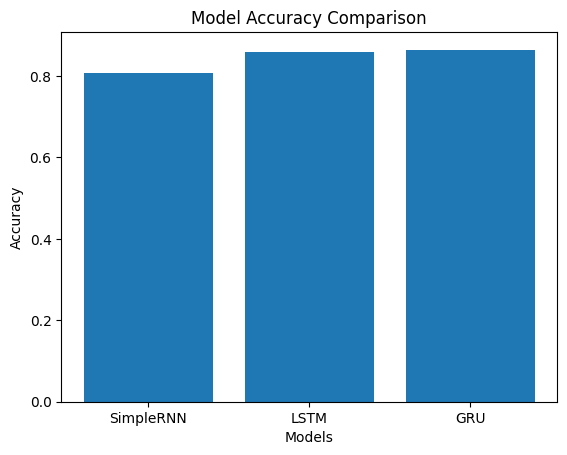

In [150]:
import matplotlib.pyplot as plt

models = ['SimpleRNN', 'LSTM', 'GRU']
accuracies = [rnn_acc, lstm_acc, gru_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

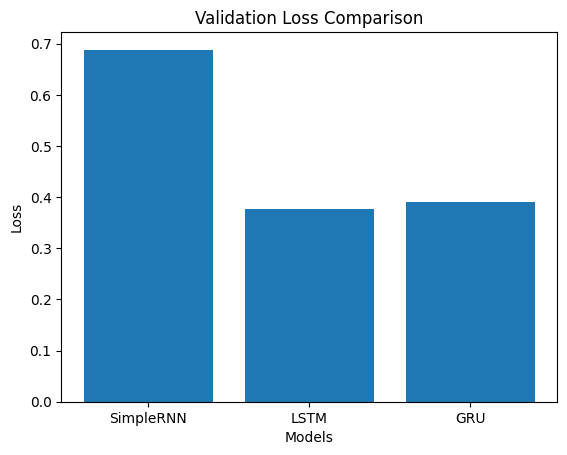

In [151]:
val_losses = [rnn_val_loss, lstm_val_loss, gru_val_loss]

plt.figure()
plt.bar(models, val_losses)
plt.title("Validation Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")
plt.show()

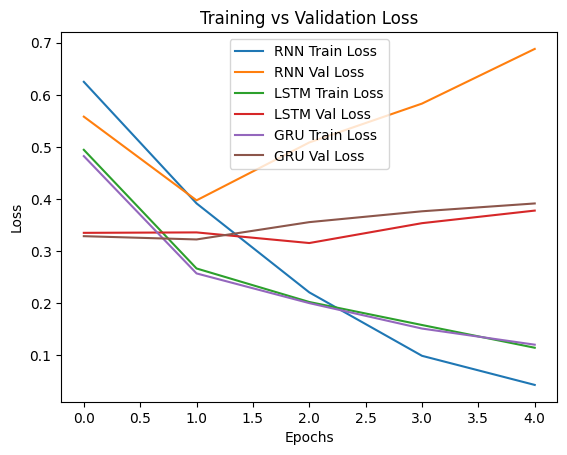

In [152]:
plt.figure()

plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Val Loss')

plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val Loss')

plt.plot(history_gru.history['loss'], label='GRU Train Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

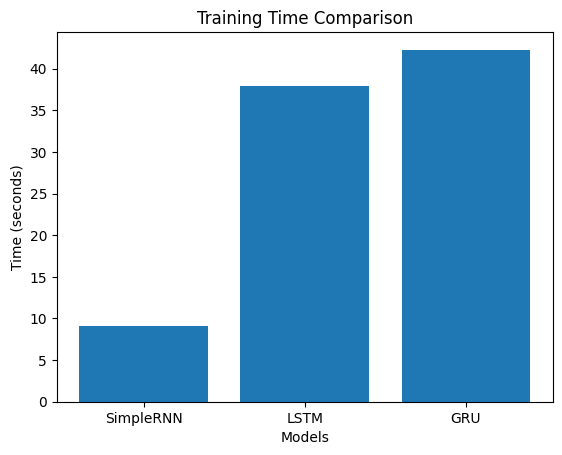

In [153]:
training_times = [rnn_time, lstm_time, gru_time]

plt.figure()
plt.bar(models, training_times)
plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")
plt.show()

In [154]:
from tensorflow.keras.datasets import imdb

word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        if word in word_index and word_index[word] < 10000:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)  # unknown word
    return encoded

In [155]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

def predict_review(model, text):
    encoded = encode_review(text)
    padded = pad_sequences([encoded], maxlen=max_length)
    
    prediction = model.predict(padded, verbose=0)[0][0]
    
    sentiment = "Positive" if prediction >= 0.5 else "Negative"
    
    return sentiment, prediction

In [156]:
reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute.",
    "The movie was boring and a complete waste of time.",
    "The acting was good but the story was average."
]

In [157]:
for i, review in enumerate(reviews, 1):
    print(f"\nReview {i}: {review}")
    
    rnn_result, rnn_score = predict_review(rnn_model, review)
    lstm_result, lstm_score = predict_review(lstm_model, review)
    gru_result, gru_score = predict_review(gru_model, review)
    
    print("\nSimpleRNN:")
    print("Sentiment:", rnn_result, "| Confidence:", round(rnn_score, 4))
    
    print("\nLSTM:")
    print("Sentiment:", lstm_result, "| Confidence:", round(lstm_score, 4))
    
    print("\nGRU:")
    print("Sentiment:", gru_result, "| Confidence:", round(gru_score, 4))


Review 1: This movie was absolutely fantastic and I enjoyed every minute.

SimpleRNN:
Sentiment: Negative | Confidence: 0.028

LSTM:
Sentiment: Positive | Confidence: 0.5825

GRU:
Sentiment: Positive | Confidence: 0.9937

Review 2: The movie was boring and a complete waste of time.

SimpleRNN:
Sentiment: Negative | Confidence: 1e-04

LSTM:
Sentiment: Negative | Confidence: 0.0104

GRU:
Sentiment: Negative | Confidence: 0.0083

Review 3: The acting was good but the story was average.

SimpleRNN:
Sentiment: Negative | Confidence: 0.0314

LSTM:
Sentiment: Negative | Confidence: 0.1998

GRU:
Sentiment: Positive | Confidence: 0.7766


In [158]:
rnn_model.save("rnn_model.keras")
lstm_model.save("lstm_model.keras")
gru_model.save("gru_model.keras")